# Hito 1: Auditoría de Datos

El objetivo de este notebook es inspeccionar visualmente y auditivamente las pistas (stems) que hemos extraído con **Demucs** antes de pasarlas a **Basic Pitch**.

Vamos a analizar la pista de **bajo** de la canción *Invierno del 92*.

In [8]:
%pip install librosa matplotlib soundfile IPython


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import IPython.display as ipd

# Ruta al stem extraído por Demucs
file_path = "separated/htdemucs/Invierno del 92 [oRsZu_EdBWc]/bass.wav"

# Cargamos los primeros 30 segundos para no saturar la memoria ni alargar el tiempo de carga
y, sr = librosa.load(file_path, duration=30.0)

print(f"Frecuencia de muestreo: {sr} Hz")
print(f"Duración cargada: {len(y)/sr} segundos")

Frecuencia de muestreo: 22050 Hz
Duración cargada: 30.0 segundos


### 1. Escuchar la pista aislada
Es vital escuchar si Demucs dejó algún residuo de batería o voz en la pista del bajo. Haz click en el reproductor:

In [10]:
ipd.Audio(y, rate=sr)

### 2. Forma de Onda (Waveform)
Observamos la amplitud de la señal en el tiempo. Nos ayuda a ver los "golpes" o ataques de las notas.

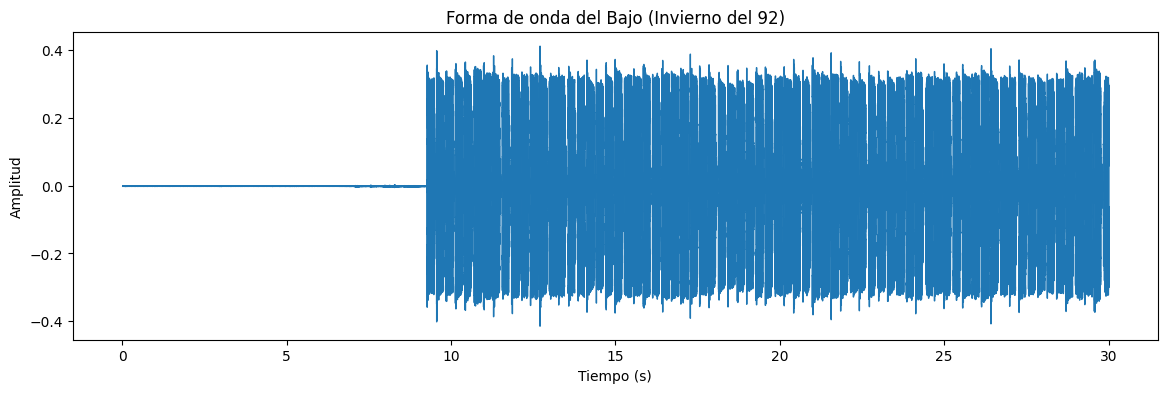

In [11]:
plt.figure(figsize=(14, 4))
librosa.display.waveshow(y, sr=sr)
plt.title('Forma de onda del Bajo (Invierno del 92)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.show()

### 3. Espectrograma de Mel
El espectrograma nos permite ver la energía de las frecuencias a lo largo del tiempo. Aquí es donde podremos detectar visualmente si hay "ruido" en altas frecuencias que nuestro posterior procesamiento de señal (DSP, como filtros paso bajo) deberá limpiar para no confundir a la IA.

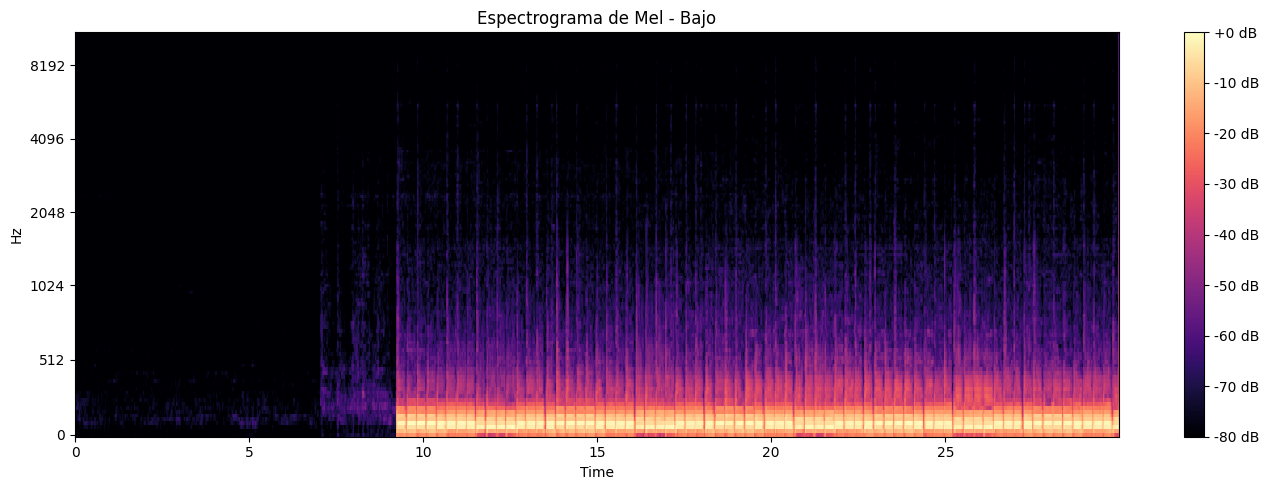

In [12]:
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_dB = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(14, 5))
librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Espectrograma de Mel - Bajo')
plt.tight_layout()
plt.show()